# Linear Algebra - Visual Intuition

This notebook makes every concept **visible** with plots.
Run each cell and look at the pictures - that's how you build intuition!

**Goal**: See the geometry behind the math.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

---
## 1. Vectors Are Arrows

A vector `[x, y]` is an arrow from the origin `(0,0)` to the point `(x,y)`.

Let's draw 3 vectors to see what they look like.

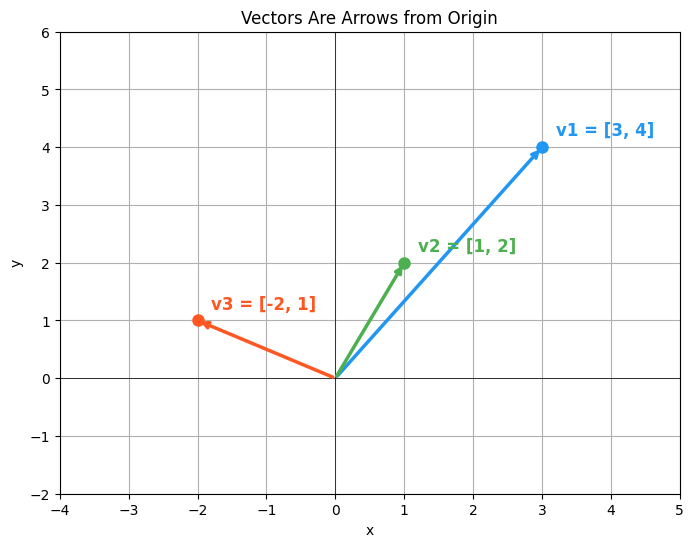

In [2]:
fig, ax = plt.subplots()

vectors = {
    'v1 = [3, 4]':  np.array([3, 4]),
    'v2 = [1, 2]':  np.array([1, 2]),
    'v3 = [-2, 1]': np.array([-2, 1]),
}

colors = ['#2196F3', '#4CAF50', '#FF5722']

for (label, v), color in zip(vectors.items(), colors):
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.plot(*v, 'o', color=color, markersize=8)
    ax.text(v[0] + 0.2, v[1] + 0.2, label, fontsize=12, color=color, fontweight='bold')

ax.set_xlim(-4, 5)
ax.set_ylim(-2, 6)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Vectors Are Arrows from Origin')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
plt.show()

---
## 2. Vector Addition = Triangle Rule

To add vectors **visually**: follow arrow `a`, then from the tip follow arrow `b`.
The result `a + b` is the arrow from origin to the final point.

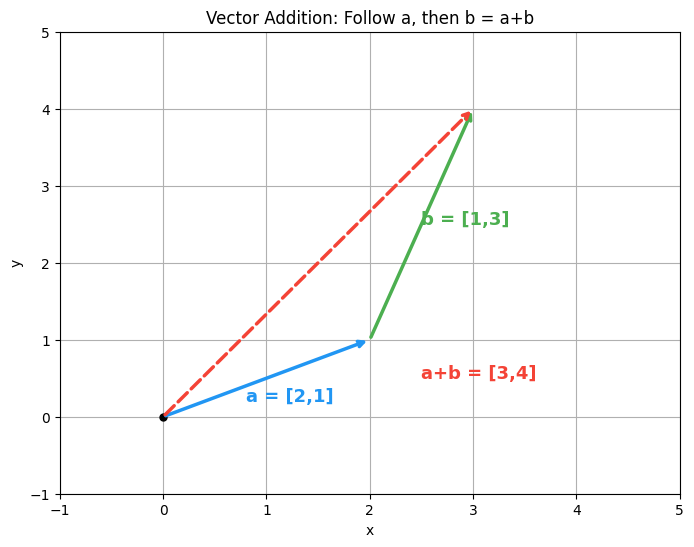

In [3]:
fig, ax = plt.subplots()

a = np.array([2, 1])
b = np.array([1, 3])
c = a + b

ax.annotate('', xy=a, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2.5))
ax.annotate('', xy=c, xytext=a,
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
ax.annotate('', xy=c, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5, linestyle='--'))

ax.text(0.8, 0.2, 'a = [2,1]', fontsize=13, color='#2196F3', fontweight='bold')
ax.text(2.5, 2.5, 'b = [1,3]', fontsize=13, color='#4CAF50', fontweight='bold')
ax.text(2.5, 0.5, f'a+b = [{c[0]},{c[1]}]', fontsize=13, color='#F44336', fontweight='bold')

ax.plot([0], [0], 'ko', markersize=5)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_title('Vector Addition: Follow a, then b = a+b')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

---
## 3. Scalar Multiplication = Stretch & Flip

Multiplying a vector by a number:
- `2 * v` = stretch to double length
- `0.5 * v` = shrink to half
- `-1 * v` = flip direction

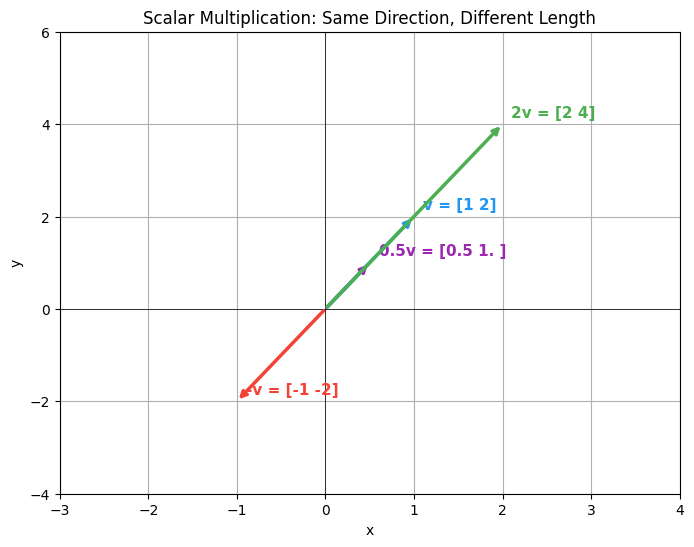

In [4]:
fig, ax = plt.subplots()

v = np.array([1, 2])
scalars = [0.5, 1, 2, -1]
labels = ['0.5v', 'v', '2v', '-v']
colors = ['#9C27B0', '#2196F3', '#4CAF50', '#F44336']

for s, label, color in zip(scalars, labels, colors):
    sv = s * v
    ax.annotate('', xy=sv, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(sv[0] + 0.1, sv[1] + 0.15, f'{label} = {sv}', fontsize=11, color=color, fontweight='bold')

ax.set_xlim(-3, 4)
ax.set_ylim(-4, 6)
ax.set_title('Scalar Multiplication: Same Direction, Different Length')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

---
## 4. Dot Product & Angle Between Vectors

The dot product tells you the **angle relationship**:
- **dot > 0**: acute angle (green) — vectors are friends
- **dot = 0**: right angle (blue) — perpendicular
- **dot < 0**: obtuse angle (red) — vectors are enemies

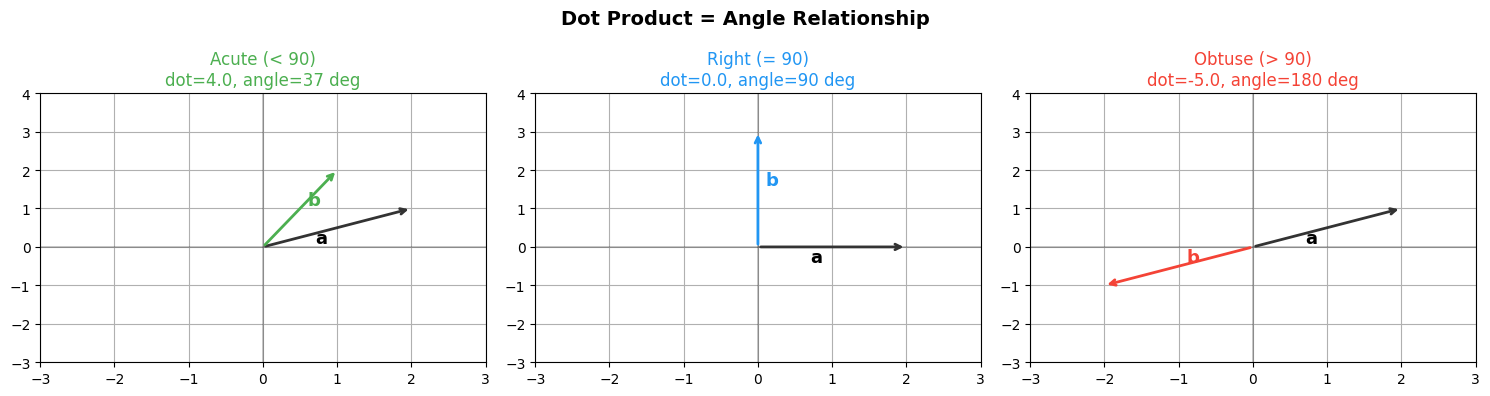

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    (np.array([2, 1]),  np.array([1, 2]),  'Acute (< 90)', '#4CAF50'),
    (np.array([2, 0]),  np.array([0, 3]),  'Right (= 90)',  '#2196F3'),
    (np.array([2, 1]),  np.array([-2, -1]),'Obtuse (> 90)','#F44336'),
]

for ax, (a, b, title, color) in zip(axes, pairs):
    dot = np.dot(a, b)
    angle = np.degrees(np.arccos(np.clip(dot / (np.linalg.norm(a) * np.linalg.norm(b)), -1, 1)))

    ax.annotate('', xy=a, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='#333', lw=2))
    ax.annotate('', xy=b, xytext=(0,0), arrowprops=dict(arrowstyle='->', color=color, lw=2))

    ax.text(a[0]*0.5 - 0.3, a[1]*0.5 - 0.4, 'a', fontsize=13, fontweight='bold')
    ax.text(b[0]*0.5 + 0.1, b[1]*0.5 + 0.1, 'b', fontsize=13, fontweight='bold', color=color)
    ax.set_title(f'{title}\ndot={dot:.1f}, angle={angle:.0f} deg', fontsize=12, color=color)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 4)
    ax.axhline(y=0, color='k', linewidth=0.3)
    ax.axvline(x=0, color='k', linewidth=0.3)

plt.suptitle('Dot Product = Angle Relationship', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Matrix Transformations = Grid Deformation

A matrix transforms ALL of space. Here we draw a grid, then see how each matrix deforms it.

- **Identity**: no change
- **Scale**: stretch x2, shrink y to 0.5
- **Rotation 45**: rotate everything 45 degrees
- **Shear**: push right proportionally to height

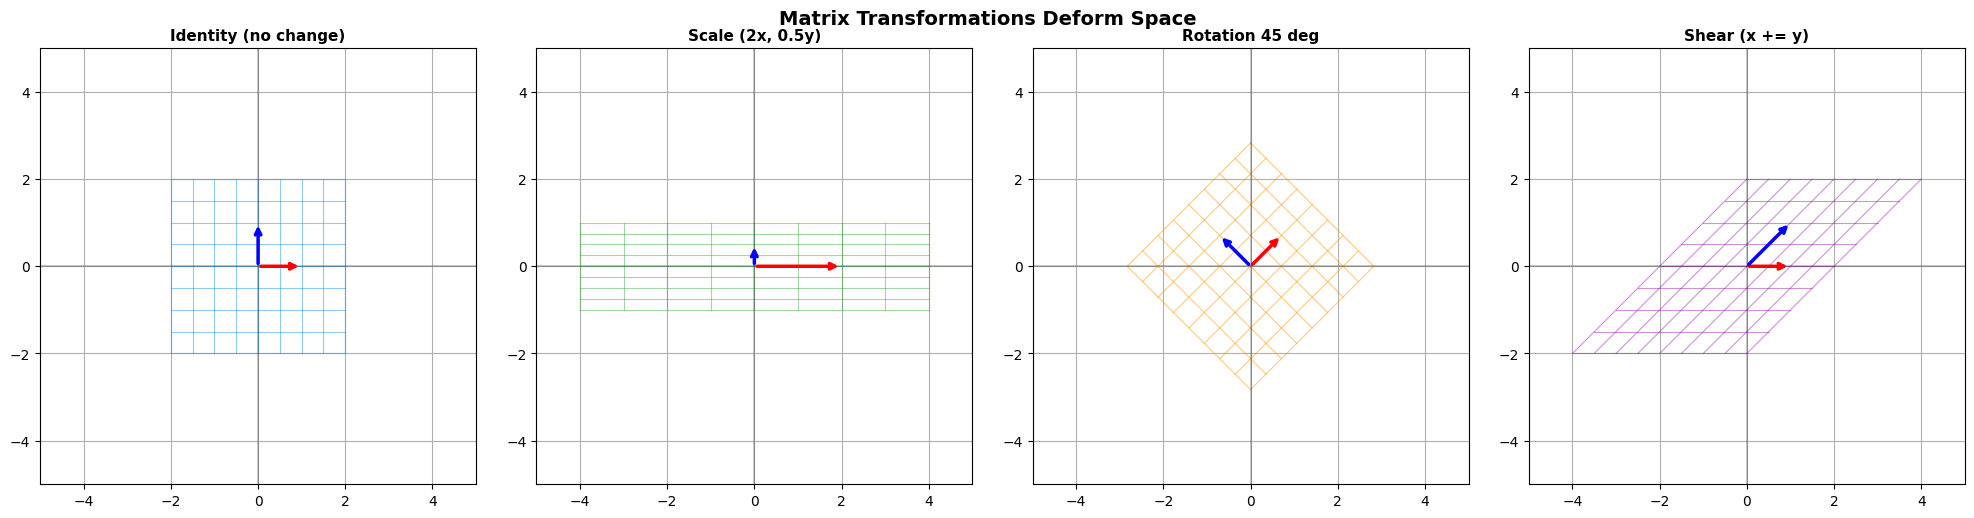

In [6]:
def draw_grid(ax, matrix, title, color):
    xs = np.linspace(-2, 2, 9)
    ys = np.linspace(-2, 2, 9)

    for x in xs:
        line_points = np.array([matrix @ np.array([x, y]) for y in ys])
        ax.plot(line_points[:, 0], line_points[:, 1], color=color, alpha=0.5, linewidth=0.8)
    for y in ys:
        line_points = np.array([matrix @ np.array([x, y]) for x in xs])
        ax.plot(line_points[:, 0], line_points[:, 1], color=color, alpha=0.5, linewidth=0.8)

    basis = np.eye(2)
    for i, c in enumerate(['red', 'blue']):
        transformed = matrix @ basis[:, i]
        ax.annotate('', xy=transformed, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color=c, lw=2.5))

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linewidth=0.3)
    ax.axvline(x=0, color='k', linewidth=0.3)

theta = np.pi / 4

transforms = [
    (np.eye(2),                        'Identity (no change)',    '#2196F3'),
    (np.array([[2,0],[0,0.5]]),        'Scale (2x, 0.5y)',       '#4CAF50'),
    (np.array([[np.cos(theta), -np.sin(theta)],
               [np.sin(theta),  np.cos(theta)]]), 'Rotation 45 deg', '#FF9800'),
    (np.array([[1,1],[0,1]]),          'Shear (x += y)',          '#9C27B0'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (m, title, color) in zip(axes, transforms):
    draw_grid(ax, m, title, color)

plt.suptitle('Matrix Transformations Deform Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Determinant = Area Change

Start with a **unit square** (area = 1). After transformation, it becomes a parallelogram.

- **det = 6**: area becomes 6 (stretched)
- **det = 1**: area stays 1 (rotation preserves area)
- **det = 0**: area becomes 0 (collapsed to a line!)

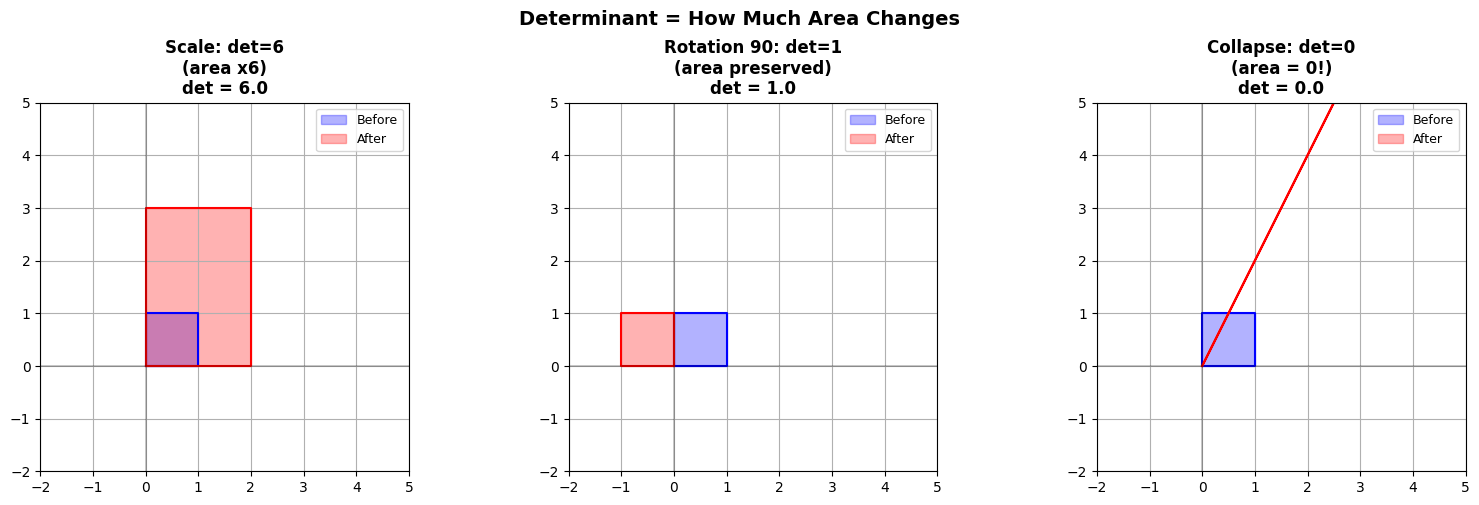

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

unit_square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]])

matrices = [
    (np.array([[2,0],[0,3]]),  'Scale: det=6\n(area x6)'),
    (np.array([[0,-1],[1,0]]), 'Rotation 90: det=1\n(area preserved)'),
    (np.array([[1,2],[2,4]]),  'Collapse: det=0\n(area = 0!)'),
]

for ax, (M, title) in zip(axes, matrices):
    ax.fill(unit_square[:,0], unit_square[:,1], alpha=0.3, color='blue', label='Before')
    transformed = np.array([M @ p for p in unit_square])
    ax.fill(transformed[:,0], transformed[:,1], alpha=0.3, color='red', label='After')
    ax.plot(*unit_square.T, 'b-', linewidth=1.5)
    ax.plot(*transformed.T, 'r-', linewidth=1.5)
    det_val = np.linalg.det(M)
    ax.set_title(f'{title}\ndet = {det_val:.1f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(-2, 5)
    ax.set_ylim(-2, 5)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linewidth=0.3)
    ax.axvline(x=0, color='k', linewidth=0.3)

plt.suptitle('Determinant = How Much Area Changes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Eigenvectors: Directions That Don't Rotate

When you apply a matrix transformation, most vectors change direction.

**Eigenvectors** are special: they only **stretch** (or shrink), never rotate.

The red arrows = eigenvectors. Notice they stay on the same line!

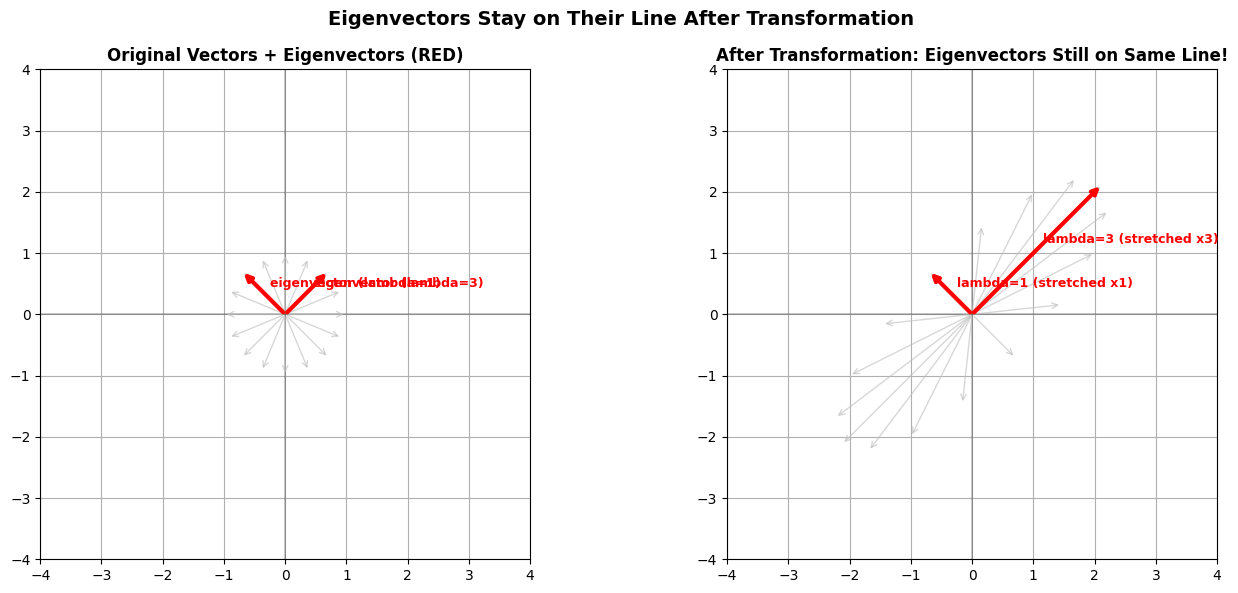

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

A = np.array([[2, 1],
              [1, 2]])

eigenvalues, eigenvectors = np.linalg.eig(A)

for ax_idx, (show_transformed, title) in enumerate([
    (False, 'Original Vectors + Eigenvectors (RED)'),
    (True,  'After Transformation: Eigenvectors Still on Same Line!'),
]):
    ax = axes[ax_idx]
    angles = np.linspace(0, 2*np.pi, 16, endpoint=False)
    for angle in angles:
        v = np.array([np.cos(angle), np.sin(angle)])
        if show_transformed:
            v_draw = A @ v
        else:
            v_draw = v
        ax.annotate('', xy=v_draw, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='#BDBDBD', lw=1, alpha=0.6))

    for i in range(2):
        v = eigenvectors[:, i]
        lam = eigenvalues[i]
        if show_transformed:
            v_draw = A @ v
            label = f'lambda={lam:.0f} (stretched x{lam:.0f})'
        else:
            v_draw = v
            label = f'eigenvector (lambda={lam:.0f})'
        ax.annotate('', xy=v_draw, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='red', lw=3))
        ax.text(v_draw[0]*0.5 + 0.1, v_draw[1]*0.5 + 0.1, label,
                fontsize=9, color='red', fontweight='bold')

    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axhline(y=0, color='k', linewidth=0.3)
    ax.axvline(x=0, color='k', linewidth=0.3)

plt.suptitle('Eigenvectors Stay on Their Line After Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Linear Independence: Spanning vs Collapsing

**Independent** vectors `[1,0]` and `[0,1]` span the full 2D plane.

**Dependent** vectors `[1,0]` and `[2,0]` only span a 1D line.

All combinations of dependent vectors lie on the same line — they can't reach the full space!

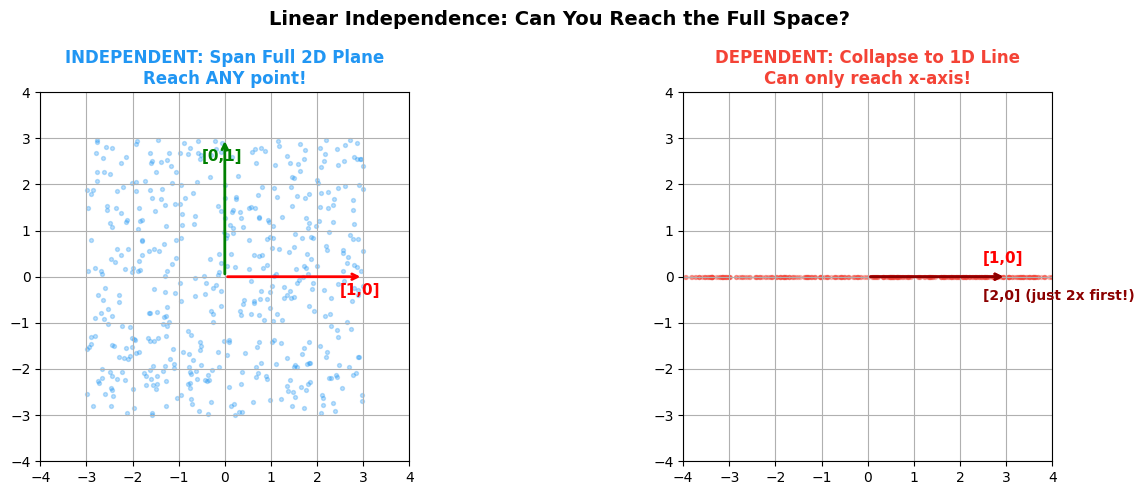

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

num_combinations = 500

# Independent: [1,0] and [0,1]
ax = axes[0]
a1, b1 = np.array([1, 0]), np.array([0, 1])
scalars_a = np.random.uniform(-3, 3, num_combinations)
scalars_b = np.random.uniform(-3, 3, num_combinations)
points = np.array([s*a1 + t*b1 for s, t in zip(scalars_a, scalars_b)])
ax.scatter(points[:, 0], points[:, 1], alpha=0.3, s=8, c='#2196F3')
ax.annotate('', xy=a1*3, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.annotate('', xy=b1*3, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(2.5, -0.4, '[1,0]', color='red', fontweight='bold', fontsize=11)
ax.text(-0.5, 2.5, '[0,1]', color='green', fontweight='bold', fontsize=11)
ax.set_title('INDEPENDENT: Span Full 2D Plane\nReach ANY point!', fontsize=12, fontweight='bold', color='#2196F3')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')

# Dependent: [1,0] and [2,0]
ax = axes[1]
a2, b2 = np.array([1, 0]), np.array([2, 0])
points2 = np.array([s*a2 + t*b2 for s, t in zip(scalars_a, scalars_b)])
ax.scatter(points2[:, 0], points2[:, 1], alpha=0.3, s=8, c='#F44336')
ax.annotate('', xy=a2*3, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.annotate('', xy=b2*1.5, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='darkred', lw=2))
ax.text(2.5, 0.3, '[1,0]', color='red', fontweight='bold', fontsize=11)
ax.text(2.5, -0.5, '[2,0] (just 2x first!)', color='darkred', fontweight='bold', fontsize=10)
ax.set_title('DEPENDENT: Collapse to 1D Line\nCan only reach x-axis!', fontsize=12, fontweight='bold', color='#F44336')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')

plt.suptitle('Linear Independence: Can You Reach the Full Space?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()